In [1]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *

In [ ]:
# parameters
# Operations = [1,2,3,4,5,6,7]
Operations = [1, 2, 3, 4]
J= len(Operations)
Ressources = [1,2,3,4,5,6,7,8]
R= len(Ressources)
T= 16

predecessors = [[],             # Step 1: Station 0_Input
                [0],            # Step 2: Station 1_stearing
                [0],            # Step 2: Station 2_stearing
                [0],            # Step 2: Station 3_stearing
                [1, 2, 3],      # Step 3: Station 4_light
                [1, 2, 3],      # Step 3: Station 5_light
                [1, 2, 3],      # Step 3: Station 6_light
                [4, 5, 6]]      # Step 4: Station 7_Output

#duration = [2, 3, 2, 4, 1, 2, 1]
duration = [2, 3, 2, 1]

#demand_capacity =  [[1, 1, 2, 1, 1, 1, 4],
#                    [2, 1, 1, 2, 1, 1, 3],
#                    [1, 2, 1, 1, 1, 1, 1],
#                    [1, 2, 1, 1, 1, 1, 1],
#                    [1, 2, 3, 1, 3, 1, 2],
#                    [1, 2, 1, 1, 1, 1, 2],
#                    [3, 3, 3, 3, 3, 3, 3]]
demand_capacity= [[1, 2, 2, 1, 1, 2, 1], [1, 1, 2, 1, 1, 1, 4], [2, 1, 1, 2, 1, 1, 3], [1, 2, 1, 1, 1, 1, 1]]

FEZ= [0,0,0,0,0,0,0]
SEZ= [15,15,15,15,15,15,15] 

capacity= [10,10,10,10,10,10,10]

In [3]:
# allowed machines
variants= {0: [[0], [1,2,3], [5], [7]], 1: [[0], [1,2,3], [4,6], [7]], 2: [[0], [1], [6], [7]]}
allowed_machines= {}

for v in variants:
    for j in range(len(variants[v])):
        allowed_machines.update({(v,j): variants[v][j]})

In [4]:
m = gp.Model("RCPSP")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2726523
Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de


In [ ]:
# decision variables
S = m.addVars(J, T, vtype= GRB.BINARY) # ==1 if job j starts in time t
Y = m.addVars(J, R, vtype=GRB.BINARY) # ==1 if job j is on maschine r
C = m.addVar(lb= 0, vtype= GRB.CONTINUOUS) # makespan

In [6]:
m.setObjective(C, GRB.MINIMIZE)

In [7]:
# time constraint
for j in range(J):
    m.addConstr(C >= sum((t + duration[j]) * S[j,t] for t in range(FEZ[j], SEZ[j]+1)))

In [8]:
# timeslot constraint
# the job needs to be finished in a certain timeframe
for j in range(J):
    m.addConstr((quicksum(S[j, t] for t in range(FEZ[j], SEZ[j]+1)) == 1))

In [9]:
# variant_based useable machines
# variants are allowed to be produced on a predefined set of machines
for j in range(J):
    m.addConstr(quicksum(Y[j,r] for r in allowed_machines[(v,j)]) == 1)

In [10]:
# variant_based
# forbid the execution of jobs on machines which aren't in the set
for j in range(J):
    for r in range(R):
        if r not in allowed_machines[(v,j)]:
            m.addConstr(Y[j,r] == 0)


In [11]:
# precendence constraint
# realise the order of the correct process
for j in range(J):
        for h in predecessors[j]:
                m.addConstr(quicksum(t * S[h, t] for t in range(FEZ[h], SEZ[h]+1)) <= quicksum((t - duration[h]) * S[j, t] for t in range(FEZ[j], SEZ[j]+1)))

In [12]:
# capacity constraint
# the defined capacity needs to be kept
for r in range(R):
    for t in range(T):
        m.addConstr((quicksum(Y[j,r] * quicksum(S[j,q] for q in range(t, min(t+duration[j], T))) for j in range(J)) <= 1))

In [13]:
# Solve
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 43 rows, 97 columns and 254 nonzeros
Model fingerprint: 0xcf1bf033
Model has 128 quadratic constraints
Variable types: 1 continuous, 96 integer (96 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [1e+00, 1e+00]
Presolve removed 43 rows and 97 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 5 

Op

In [376]:
#m.computeIIS()
#m.write("rcpsp.ilp")

In [14]:
print("Objective value: ", m.objVal , " found after ", m.Runtime, " seconds. Relative gap is: ", m.MIPGap)

Objective value:  5.0  found after  0.023999929428100586  seconds. Relative gap is:  0.0


In [ ]:
# Nicolas try:

In [61]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *


Operations = [1, 2, 3, 4]
J= len(Operations)
Ressources = [1,2,3,4,5,6,7,8]
R= len(Ressources)


predecessors = [
    [],     # j0
    [0],    # j1 nach j0
    [1],    # j2 nach j1
    [2]     # j3 nach j2
]

duration = [[1, 3, 2, 1], [1, 2, 2, 3], [1, 1, 2, 3]]

q = {0: 20, 1: 20, 2: 20} # number of cars produced per Variant


# allowed machines
variants= {0: [[0], [1,2,3], [5], [7]], 1: [[0], [1,2,3], [4,6], [7]], 2: [[0], [1], [6], [7]]}
allowed_machines= {}

V = len(variants)

for v in variants:
    for j in range(len(variants[v])):
        allowed_machines.update({(v,j): variants[v][j]})

cars = [] # each car produced of each variant becomes it's own entity
for v in variants.keys():
    for idx in range(q[v]):
        cars.append((v, idx))

CARS = len(cars)
type_of = {c: cars[c][0] for c in range(CARS)}

sum_d = sum(duration[0])
T= 150
#T = CARS * sum_d   # safe upper bound
#T = int((CARS * sum_d) / max(1, R//2)) + 50 #heuristic
FEZ = [0]*J
SEZ = [T-1]*J

m = gp.Model("RCPSP")

# decision variables
S = m.addVars(CARS, J, T, vtype= GRB.BINARY) # ==1 if job j starts for car c in time t
Y = m.addVars(CARS, J, R, vtype=GRB.BINARY) # ==1 if job j is for car c on maschine r
C = m.addVar(lb= 0, vtype= GRB.CONTINUOUS) # makespan

# Objective
m.setObjective(C, GRB.MINIMIZE)

# Constraints

# time constraint
for c in range(CARS):
    for j in range(J):
        m.addConstr(C >= sum((t + duration[type_of[c]][j]) * S[c,j,t] for t in range(FEZ[j], SEZ[j]+1)))

# timeslot constraint
# the job needs to be finished in a certain timeframe
for c in range(CARS):
    for j in range(J):
        m.addConstr((quicksum(S[c, j, t] for t in range(FEZ[j], SEZ[j]+1)) == 1))

# variant_based useable machines
# variants are allowed to be produced on a predefined set of machines
for c in range(CARS):
    v = type_of[c]
    for j in range(J):
        m.addConstr(quicksum(Y[c,j,r] for r in allowed_machines[(v,j)]) == 1)
        for r in range(R):
            if r not in allowed_machines[(v,j)]:
                m.addConstr(Y[c,j,r] == 0)

# precendence constraint
# realise the order of the correct process
for c in range(CARS):
    for j in range(J):
            for h in predecessors[j]:
                    m.addConstr(quicksum(t * S[c,h, t] for t in range(FEZ[h], SEZ[h]+1)) + duration[type_of[c]][h] <= quicksum(t * S[c,j, t] for t in range(FEZ[j], SEZ[j]+1)))

# capacity constraint
# the defined capacity needs to be kept
for r in range(R):
    for t in range(T):
        m.addConstr((quicksum(Y[c,j,r] * quicksum(S[c,j,q] for q in range(max(FEZ[j], t - duration[type_of[c]][j] + 1), min(SEZ[j], t) + 1)) for c in range(CARS) for j in range(J)) <= 1))

latest = {(c,j): min(SEZ[j], T - duration[type_of[c]][j]) for c in range(CARS) for j in range(J)}
# ensuring that no job ende after the defined periods
# for c in range(CARS):
#     for j in range(J):
#         for t in range(T):
#             if t < FEZ[j] or t > latest[(c,j)]:
#                 m.addConstr(S[c,j,t] == 0)

# each variant can only be at a machine at the same time
for c in range(CARS):
    for t in range(T):
        m.addConstr(gp.quicksum(gp.quicksum(S[c,j,q] for q in range(max(FEZ[j], t - duration[type_of[c]][j] + 1), min(latest[(c,j)], t) + 1)) for j in range(J)) <= 1)

# Solve
m.optimize()


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 11480 rows, 37921 columns and 193280 nonzeros
Model fingerprint: 0x508d39e6
Model has 1200 quadratic constraints
Variable types: 1 continuous, 37920 integer (37920 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+00]
  QRHS range       [1e+00, 1e+00]
Presolve removed 1366 rows and 2840 columns
Presolve time: 0.56s
Presolved: 36884 rows, 55321 columns, 340660 nonzeros
Variable types: 0 continuous, 55321 integer (55180 binary)
Deterministic concurrent LP optimizer: primal and dual

In [62]:
import matplotlib.pyplot as plt
from collections import defaultdict

def extract_schedule_cars(S, Y, duration, CARS, J, R, T, eps=0.5):
    """
    Returns list of (machine, start, dur, car, job).
    """
    # start time per (c,j)
    start = {}
    for (c, j, t), var in S.items():
        if var.X > eps:
            start[(c, j)] = t

    # machine per (c,j)
    mach = {}
    for (c, j, r), var in Y.items():
        if var.X > eps:
            mach[(c, j)] = r

    sched = []
    for c in range(CARS):
        for j in range(J):
            sched.append((mach[(c, j)], start[(c, j)], duration[type_of[c]][j], c, j))
    return sched

def plot_gantt_per_machine_cars(schedule, type_of, makespan=None, T=None,
                                title="Gantt per machine (each car shown)",
                                show_labels=False):
    """
    schedule: list (r, start, dur, c, j)
    type_of: dict car -> variant
    """
    if makespan is None:
        makespan = max(s + d for r, s, d, c, j in schedule)
    if T is None:
        T = makespan

    machines = sorted({r for r, *_ in schedule})
    y_pos = {r: i for i, r in enumerate(machines)}

    # colors by variant
    variants = sorted({type_of[c] for _, _, _, c, _ in schedule})
    cmap = plt.get_cmap("tab10")
    v_color = {v: cmap(i % 10) for i, v in enumerate(variants)}

    # group segments per machine+variant for faster plotting
    segs = defaultdict(list)   # (r, v) -> [(start, dur), ...]
    texts = defaultdict(list)  # r -> [(x, y, label), ...]

    for r, start, dur, c, j in schedule:
        v = type_of[c]
        segs[(r, v)].append((start, dur))
        if show_labels:
            texts[r].append((start + dur/2, y_pos[r], f"c{c}-j{j}"))

    fig, ax = plt.subplots(figsize=(14, 0.8*len(machines) + 2))

    for r in machines:
        y = y_pos[r]
        for v in variants:
            if (r, v) in segs:
                ax.broken_barh(segs[(r, v)], (y-0.4, 0.8),
                               edgecolors="black", linewidth=0.5,
                               facecolors=v_color[v])

        if show_labels:
            for x, yy, lab in texts[r]:
                ax.text(x, yy, lab, ha="center", va="center", fontsize=6)

    ax.set_yticks([y_pos[r] for r in machines])
    ax.set_yticklabels([f"M{r}" for r in machines])
    ax.set_xlim(0, T)
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.4)

    ax.axvline(makespan, linestyle="--")
    ax.text(makespan, len(machines)-0.5, f"  C={makespan:.0f}", va="bottom")

    handles = [plt.Rectangle((0,0), 1, 1, color=v_color[v]) for v in variants]
    ax.legend(handles, [f"Variant {v}" for v in variants],
              loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()

def plot_gantt_per_car(schedule, type_of, makespan=None, T=None,
                       title="Gantt per car (each car is one row)",
                       show_labels=False, max_cars_to_label=25):
    """
    schedule: list (r, start, dur, c, j)
    """
    if makespan is None:
        makespan = max(s + d for r, s, d, c, j in schedule)
    if T is None:
        T = makespan

    cars = sorted({c for _, _, _, c, _ in schedule})
    y_pos = {c: i for i, c in enumerate(cars)}

    machines = sorted({r for r, *_ in schedule})
    cmap = plt.get_cmap("tab20")  # more colors
    r_color = {r: cmap(i % 20) for i, r in enumerate(machines)}

    # group by car+machine
    segs = defaultdict(list)  # (c, r) -> [(start, dur)]
    texts = []

    for r, start, dur, c, j in schedule:
        segs[(c, r)].append((start, dur))
        if show_labels and len(cars) <= max_cars_to_label:
            texts.append((start + dur/2, y_pos[c], f"j{j}"))

    fig, ax = plt.subplots(figsize=(14, 0.25*len(cars) + 2))

    for c in cars:
        y = y_pos[c]
        for r in machines:
            if (c, r) in segs:
                ax.broken_barh(segs[(c, r)], (y-0.4, 0.8),
                               edgecolors="black", linewidth=0.4,
                               facecolors=r_color[r])

    if show_labels and len(cars) <= max_cars_to_label:
        for x, y, lab in texts:
            ax.text(x, y, lab, ha="center", va="center", fontsize=6)

    ax.set_yticks([y_pos[c] for c in cars])
    # label as cX (vY) to show variant
    ax.set_yticklabels([f"c{c} (v{type_of[c]})" for c in cars])
    ax.set_xlim(0, T)
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.4)

    ax.axvline(makespan, linestyle="--")
    ax.text(makespan, len(cars)-0.5, f"  C={makespan:.0f}", va="bottom")

    handles = [plt.Rectangle((0,0), 1, 1, color=r_color[r]) for r in machines]
    ax.legend(handles, [f"M{r}" for r in machines],
              loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()


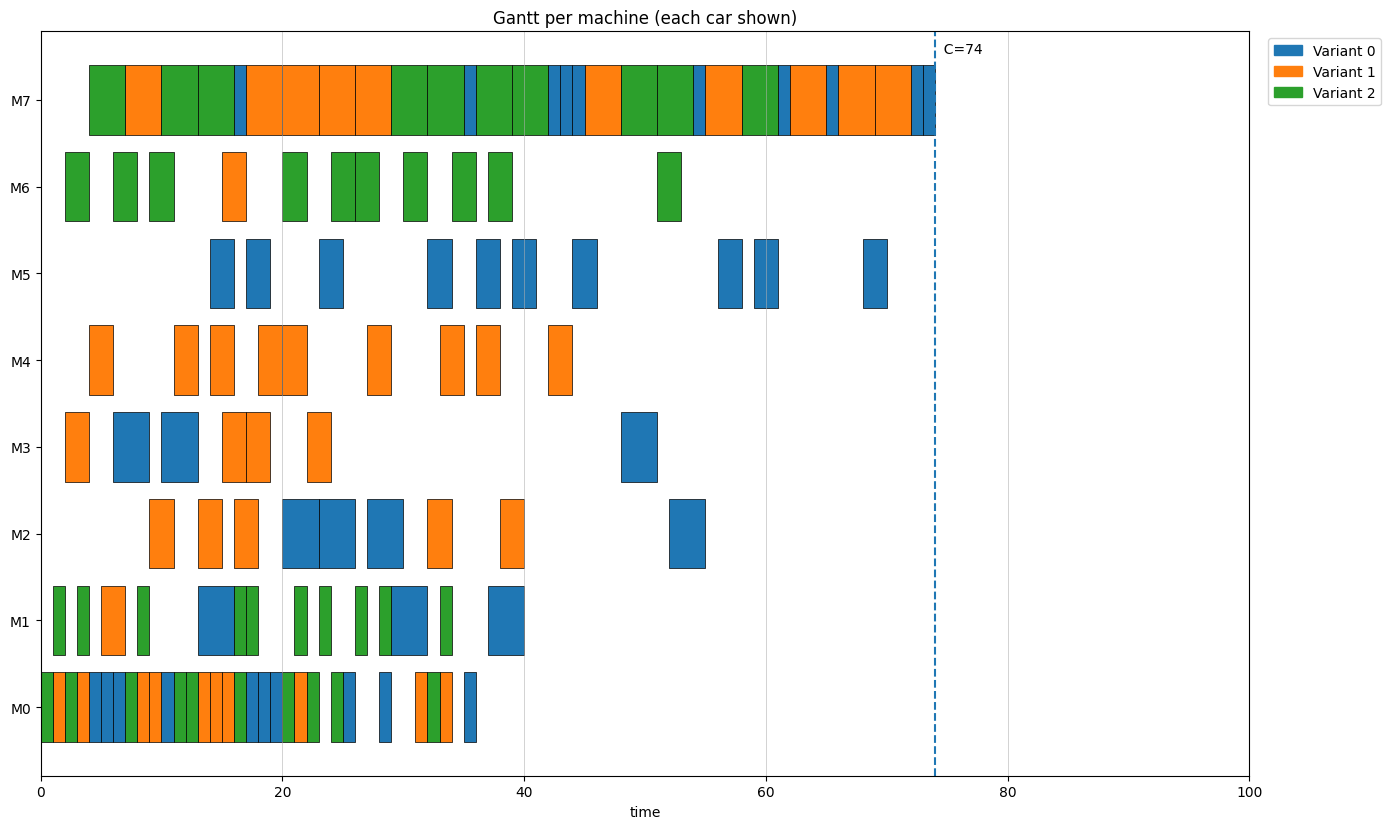

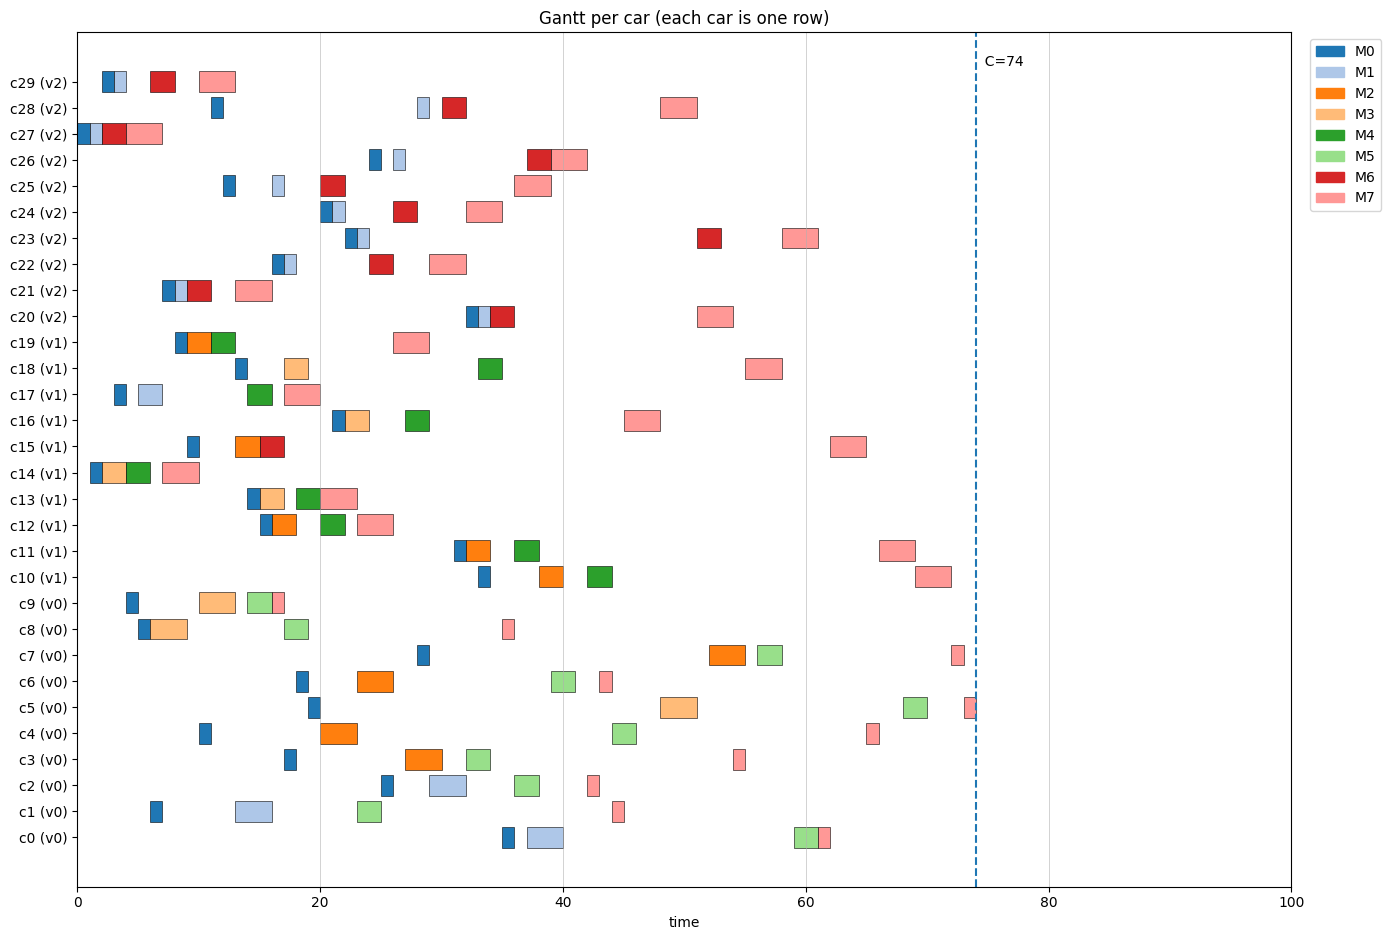

In [ ]:
if m.status == GRB.OPTIMAL:
    schedule = extract_schedule_cars(S, Y, duration, CARS, J, R, T, eps=0.5)

    # Plot 1: per machine
    plot_gantt_per_machine_cars(schedule, type_of, makespan=C.X, T=T, show_labels=False)

    # Plot 2: per car
    plot_gantt_per_car(schedule, type_of, makespan=C.X, T=T, show_labels=False)
else:
    print("No optimal solution:", m.status)
